# White House Attendance Analysis
## Teresa Ferrill
### April 12, 2026

This project analyzes publicly released White House visitor records to identify patterns in recorded activity across selected months, arrival times, named visitees, and meeting locations.

-----------------------------------------------------------------------------------------------------------------
Datasets, total of 6:  
>Visit Records for October, November, and December 2022
>Visit Records for October, November, and December 2023 
 
Dataset Source:    
>The White House Visitor Logs

---

## Introduction

This analysis examines White House visitor logs from October through December of 2022 and the same three-month period in 2023. It identifies patterns in recorded visit volume, appointment dates, arrival times, named visitees, and meeting locations.

Comparing the same months across both years provides a consistent timeframe and helps control for seasonal differences. However, the results represent only the selected six months and should not be interpreted as complete annual trends.

For counting purposes, each row is treated as a recorded visit. The available fields do not independently confirm that every scheduled or recorded access event resulted in a completed visit.

The goal is to identify patterns that may help White House operations and visitor-access leadership determine where additional operational review may be useful. The findings can inform—but should not independently determine—staffing, scheduling, facility, or resource-allocation decisions.

## Audience

The primary audience is White House operations and visitor-access leadership. Secondary audiences include executive stakeholders, policy analysts, oversight personnel, and members of the public interested in government transparency.

These audiences are expected to understand the general purpose of visitor-log data but may be more focused on operational findings than technical methods. Therefore, the visualizations emphasize clearly labeled patterns, comparisons, assumptions, and limitations rather than complex statistical explanations.

The analysis is intended to support further review of:

* Periods with higher recorded visitor activity.
* Differences between the selected 2022 and 2023 reporting periods.
* Commonly recorded days and arrival times.
* Frequently recorded visitees and meeting locations.
* Potential scheduling, staffing, and facility considerations that may require validation with additional operational information.

---

    

---

## Analysis Overview

This analysis examines how recorded White House visitor activity varies across time, named visitees, and meeting locations using six monthly visitor-log datasets.

The analysis addresses the following questions:

1. How did recorded activity vary by month between the selected 2022 and 2023 periods?
2. Which named visitees appeared most frequently in the records?
3. Which meeting locations were recorded most frequently?
4. How did recorded activity vary by day of the week and hour of the day?
5. Do the records show concentration among a relatively small number of named visitees or locations?

The analysis describes patterns in the available records. It does not determine the purpose of each visit, whether recorded access resulted in a completed visit, or whether frequently recorded individuals had greater influence or importance.

## Design Considerations

1. The visualizations were designed for clarity and accessibility rather than decoration.
2. Gestalt principles—including proximity, similarity, and alignment—were used to group related information.
3. Titles and axis labels were written to clearly identify the measure shown.
4. Spacing was used to separate visual elements and reduce clutter.
5. Figure sizes were selected to minimize label crowding.
6. Color was used consistently and selectively to make comparisons easier to follow.
7. Explanatory notes were included where necessary to clarify assumptions and limitations.

## Data Preparation

1. Six White House visitor-log files covering October through December of 2022 and 2023 were combined into a single dataframe.
2. Date fields were converted to datetime values to support consistent time-based analysis.
3. Year, month, month-year, day-of-week, and hour fields were created for the visualizations.
4. Visitee first and last names were combined into one field for analyzing frequently recorded named visitees.
5. Meeting-location values were standardized to address differences in capitalization, abbreviations, and formatting.
6. The Time of Arrival (`TOA`) field was treated as the recorded arrival time. Records with missing or invalid `TOA` values were excluded from visualizations requiring an arrival hour.
7. The analysis was limited to October through December of 2022 and the same months in 2023 to provide a consistent comparison window.
8. This scope improves comparability between the selected periods but does not represent complete annual activity for either year.
9. Each row was counted as a recorded visit. The available data does not independently confirm that every scheduled or recorded access event resulted in a completed visit.

## Visualizations

### Time-Based Trends

* **Visual 1: White House Visits by Month**
  Line chart showing changes in recorded visit volume across the selected months.

* **Visual 2: Monthly Visit Comparison**
  Bar chart comparing recorded monthly visit totals between 2022 and 2023.

* **Visual 8: Step Chart of Monthly Visits**
  Step chart providing another view of changes in recorded activity between months.

### Visitees and Locations

* **Visual 3: Top 10 Named Visitees**
  Bar chart showing the people most frequently listed in the visitee fields. These are the people recorded as being visited, not necessarily the individuals entering the White House.

* **Visual 4: Top 10 Visit Locations**
  Bar chart comparing recorded activity among meeting locations during the selected periods.

### Activity by Day and Time

* **Visual 5: Visit Activity by Hour of Day and Month**
  Heatmap showing the concentration of records by arrival hour and month.

* **Visual 6: Visit Activity by Hour and Month**
  Scatterplot showing the distribution of recorded arrival times across months.

* **Visual 7: Visits by Day of the Week**
  Bar chart comparing recorded visit totals across days of the week.

---


---

## Step 1: Load and Review the Data

Six monthly White House visitor-log datasets were selected for analysis. The files cover October through December of 2022 and the same three-month period in 2023.

Using the same months from two consecutive years provides a consistent comparison window. This period also includes several major holidays—Halloween, Thanksgiving, Christmas, and New Year’s Eve—that may affect recorded visitor activity. However, this analysis does not independently attribute changes in activity to those holidays.

### Selected Datasets

**2022**

1. October 2022
2. November 2022
3. December 2022

**2023**

1. October 2023
2. November 2023
3. December 2023

The initial data-preparation process includes:

1. Loading each monthly dataset.
2. Confirming that all six files loaded successfully.
3. Reviewing the number of rows and columns in each file.
4. Comparing column names and data types across the files.
5. Examining missing values and inconsistent formatting.
6. Combining the files into one dataframe for analysis.
7. Confirming that the appointment dates correspond to the six selected reporting months.

The resulting dataset represents the selected six-month comparison period and should not be interpreted as a complete analysis of either calendar year.

---
 

In [1]:
# Import libraries
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Locate the six source files
files = sorted(glob.glob("../data/WhiteHouseVisitLogs/*.csv"))

# Stop with a clear message if the path is incorrect
if not files:
    raise FileNotFoundError(
        "No CSV files were found in ../data/WhiteHouseVisitLogs/. "
        "Start Jupyter from the analysis folder and verify the data folder."
    )

# Read all fields as strings to avoid mixed-data-type warnings
df_list = [pd.read_csv(file, dtype=str) for file in files]

# Combine the six monthly files
df = pd.concat(df_list, ignore_index=True)

print("Files loaded:", len(files))
print("Total rows:", len(df))
print("Columns:")
print(df.columns.tolist())

display(df.head())

Files loaded: 6
Total rows: 399633
Columns:
['Last Name', 'First Name', 'Middle Initial', 'UIN', 'BDGNBR', 'Access Type', 'TOA', 'POA', 'TOD', 'POD', 'Appointment Made Date', 'Appointment Start Date', 'Appointment End Date', 'Appointment Cancel Date', 'Total People', 'Last Updated By', 'POST', 'Last Entry Date', 'Terminal Suffix', 'Visitee Last Name', 'Visitee First Name', 'Meeting Location', 'Meeting Room', 'Caller Last Name', 'Caller First Name', 'CALLER_ROOM', 'RELEASEDATE', 'Caller Room', 'Release Date']


,Last Name,First Name,Middle Initial,UIN,BDGNBR,Access Type,TOA,POA,TOD,POD,...,Visitee Last Name,Visitee First Name,Meeting Location,Meeting Room,Caller Last Name,Caller First Name,CALLER_ROOM,RELEASEDATE,Caller Room,Release Date
0,AAMLAND,SEAN,P,U91614,199467,VA,Oct 22 2022 1:02PM,NaN,NaN,NaN,...,Keefe,John,WH,WEST WING,WW,TOUR,NaN,1/30/2023,NaN,NaN
1,AARON,BRYANT,K,U92621,197377,VA,Oct 27 2022 9:04AM,NaN,NaN,A05,...,Ambrose,Eric,OEOB,Bowling Alley - 037,LARANCE,MARC,NaN,1/30/2023,NaN,NaN
2,AARON,CRAIG,A,U85739,NaN,VA,Oct 4 2022 9:04AM,NaN,NaN,NaN,...,Ward,Natalie,OEOB,350,PARSONS,NATHAN,NaN,1/30/2023,NaN,NaN
3,AASTROEMFERNLUND,KARIN,H,U86449,NaN,VA,Oct 12 2022 12:10PM,NaN,NaN,NaN,...,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,1/30/2023,NaN,NaN
4,ABALOS,JANILA,L,U94452,NaN,VA,NaN,NaN,NaN,NaN,...,Office,Visitors,WH,SOUTH LAWN,MILLS,GIONELLY,NaN,1/30/2023,NaN,NaN


This code block loads and combines the six White House visitor log datasets into one dataframe for analysis.  
All files are read as text initially to avoid mixed data type issues and then reviewed before cleaning begins.  

-----------------------------------------------------------------------------------------------------------------
Step 2: Basic cleaning steps to initially review the dataset

In [2]:
print("Original min:", df['Appointment Start Date'].min())
print("Original max:", df['Appointment Start Date'].max())
print("Total rows:", len(df))
print("Files loaded:", len(files))

# Convert appointment date to datetime
df['Appointment Start Date'] = pd.to_datetime(df['Appointment Start Date'], errors='coerce')

print("Null dates after conversion:", df['Appointment Start Date'].isna().sum())
print("Converted min:", df['Appointment Start Date'].min())
print("Converted max:", df['Appointment Start Date'].max())

# Create year/month fields for later visuals
df['year'] = df['Appointment Start Date'].dt.year
df['month'] = df['Appointment Start Date'].dt.to_period('M').astype(str)

print("Months in data:")
print(sorted(df['month'].dropna().unique()))

Original min: 10/1/2022 10:00
Original max: 12/9/2023 9:50
Total rows: 399633
Files loaded: 6
Null dates after conversion: 0
Converted min: 2022-10-01 07:00:00
Converted max: 2023-12-31 10:00:00
Months in data:
['2022-10', '2022-11', '2022-12', '2023-10', '2023-11', '2023-12']



-----------------------------------------------------------------------------------------------------------------

Step 2a: Basic cleaning steps continued:   
> Create month, day_of_week, and visitee_name  
> Combine first and last names into one visitee_name field     
> Clean category fields for plotting  

In [3]:
# Create additional time-based fields
df["day_of_week"] = df["Appointment Start Date"].dt.day_name()
df["month_num"] = df["Appointment Start Date"].dt.month
df["month_name"] = df["Appointment Start Date"].dt.strftime("%b")

# Combine visitee first and last names
df["visitee_name"] = (
    df["Visitee First Name"].fillna("").str.strip()
    + " "
    + df["Visitee Last Name"].fillna("").str.strip()
).str.strip()

# Label records without a named visitee
df["visitee_name"] = df["visitee_name"].replace("", "Unknown")

# Exclude invalid appointment dates from time-based analysis
df = df.dropna(subset=["Appointment Start Date"]).copy()

# Verify the derived fields
display(
    df[
        [
            "Appointment Start Date",
            "year",
            "month",
            "month_num",
            "month_name",
            "day_of_week",
            "visitee_name"
        ]
    ].head()
)

,Appointment Start Date,year,month,month_num,month_name,day_of_week,visitee_name
0,2022-10-22 13:00:00,2022,2022-10,10,Oct,Saturday,John Keefe
1,2022-10-27 09:00:00,2022,2022-10,10,Oct,Thursday,Eric Ambrose
2,2022-10-04 09:00:00,2022,2022-10,10,Oct,Tuesday,Natalie Ward
3,2022-10-12 12:00:00,2022,2022-10,10,Oct,Wednesday,Visitors Office
4,2022-10-31 18:45:00,2022,2022-10,10,Oct,Monday,Visitors Office


Additional cleaning steps include:

- Creating `year`, `month`, `month_num`, `month_name`, and `day_of_week` fields for time-based analysis.
- Combining visitee first and last names into a single `visitee_name` field.
- Labeling blank visitee names as `Unknown` so those records are not unintentionally omitted from counts.
- Excluding records with invalid appointment dates from time-based visualizations.

---

Visual 1: White House Visits by Month

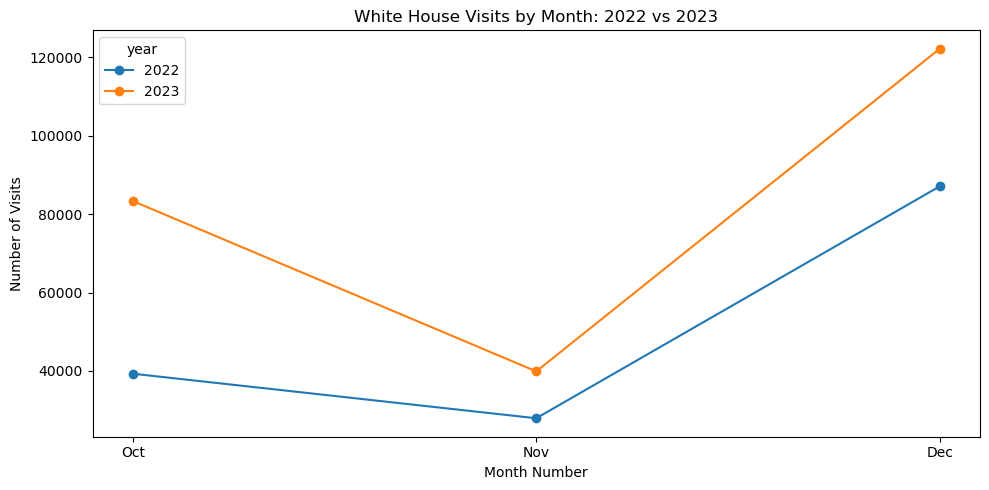

In [4]:
# Import plot library
import matplotlib.pyplot as plt

# Monthly visit counts
visits_year_compare = df.groupby(['year', 'month_num']).size().reset_index(name='count')
pivot_year = visits_year_compare.pivot(index='month_num', columns='year', values='count')

pivot_year.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('White House Visits by Month: 2022 vs 2023')
plt.xlabel('Month Number')
plt.ylabel('Number of Visits')
plt.xticks(range(10, 13), ['Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

**Chart Type:** Line Chart

**What this shows:**  
This chart shows total visit volume across October through December for 2022 and 2023.

**Insight:**  
Visit volume is higher in 2023 across all months, with a noticeable increase in October.

**Why it matters:**  
Recorded volume was higher in each selected 2023 month. Additional years and complete annual records would be needed to determine whether this represents a sustained trend or requires operational changes.

-----------------------------------------------------------------------------------------------------------------
Visual 2: Monthly Visit Comparison (Bar Chart)

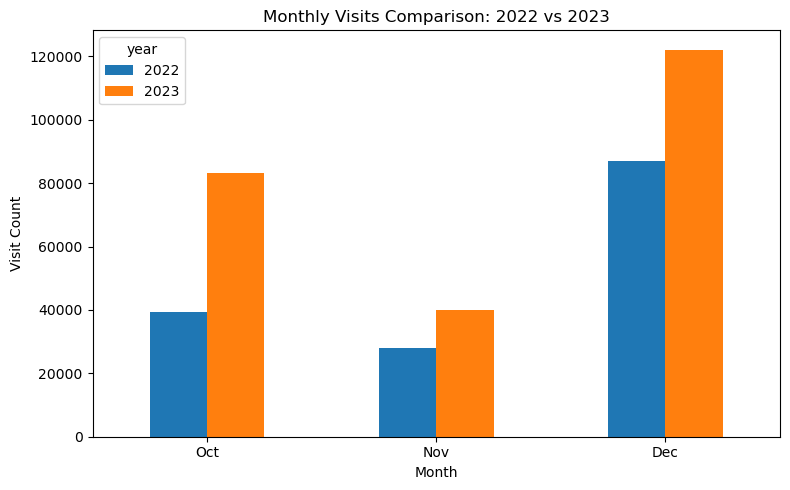

In [5]:

visits_year_compare = df.groupby(['year', 'month_name']).size().reset_index(name='count')

month_order = ['Oct', 'Nov', 'Dec']
visits_year_compare['month_name'] = pd.Categorical(
    visits_year_compare['month_name'],
    categories=month_order,
    ordered=True
)

pivot_compare = visits_year_compare.pivot(index='month_name', columns='year', values='count')

pivot_compare.plot(kind='bar', figsize=(8, 5))
plt.title('Monthly Visits Comparison: 2022 vs 2023')
plt.xlabel('Month')
plt.ylabel('Visit Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Chart Type:** Bar Chart

**What this shows:**
This grouped bar chart compares recorded visit totals for October, November, and December of 2022 with the corresponding months in 2023.

**Insight:**
Each selected month contains more records in 2023 than the corresponding month in 2022.

**Why it matters:**
Recorded volume was higher in each of the selected 2023 months. Additional years and complete annual records would be needed to determine whether this represents a sustained trend or requires operational changes.

---

Visual 3: Top 10 Named Visitees


visitee_name
Ed Teleky          7369
Kevin Ballen       4801
Amanda Trocola     3959
Dan Via            1739
Gianna Juarez      1616
Gionelly Mills     1274
Claudia Marconi    1176
Anne Neuberger     1099
JASMINE BYERS       853
Mitch Landrieu      852
Name: count, dtype: int64


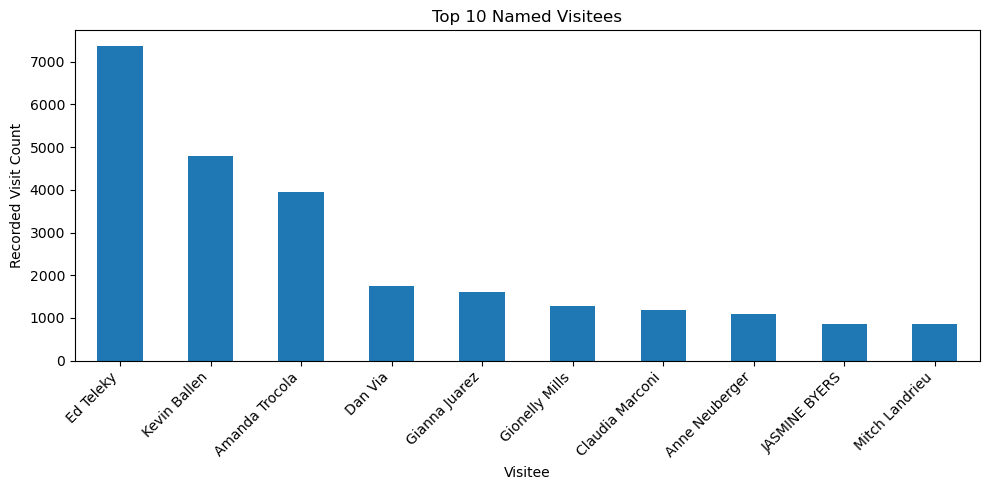

In [6]:
# Exclude unknown and non-person visitee entries
excluded_visitees = [
    "unknown",
    "visitors office",
    "room 1",
    "potus",
    "vpotus",
    "flotus"
]

# Identify the ten most frequently recorded named visitees
top_visitees = (
    df.loc[
        ~df["visitee_name"]
        .str.strip()
        .str.lower()
        .isin(excluded_visitees),
        "visitee_name"
    ]
    .value_counts()
    .head(10)
)

print(top_visitees)

# Plot the results
top_visitees.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Named Visitees")
plt.xlabel("Visitee")
plt.ylabel("Recorded Visit Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Chart Type:** Bar Chart

**What this shows:**
This chart displays the ten most frequently recorded named visitees after excluding unknown and non-person entries.

**Insight:**
Some named visitees appear more frequently than others in the selected records.

**Why it matters:**
The results identify individuals who appear frequently in the visitee fields. They do not establish the purpose, influence, importance, or completion of the associated visits.

**Note:**
This chart excludes Unknown, Visitors Office, Room 1, POTUS, VPOTUS, and FLOTUS from the visitee field so named individual visitees can be displayed more clearly. A visitee is the person listed as being visited, not necessarily the person entering the White House.

---

Visual 4: Top 10 Visit Locations


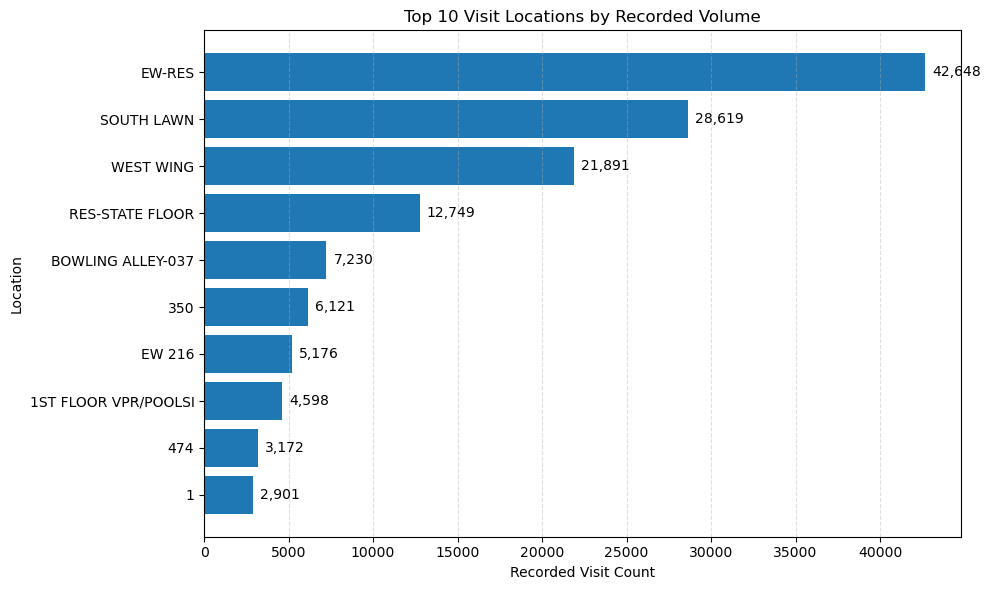

In [7]:
# Clean and standardize Meeting Room values
df["Meeting Room"] = (
    df["Meeting Room"]
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(r"\s*-\s*", "-", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

# Standardize known location variants
df["Meeting Room"] = df["Meeting Room"].replace({
    "EW RES": "EW-RES",
    "VISITORS OFFICE": "VISITOR'S OFFICE"
})

# Exclude non-informative location values
excluded_locations = [
    "ROOM 1",
    "UNKNOWN",
    "EW TOUR",
    "VISITOR'S OFFICE"
]

# Identify the ten most frequently recorded named locations
top_locations = (
    df.loc[
        ~df["Meeting Room"].isin(excluded_locations),
        "Meeting Room"
    ]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.barh(top_locations.index, top_locations.values)

# Add count labels
x_offset = top_locations.max() * 0.01

for index, value in enumerate(top_locations.values):
    plt.text(
        value + x_offset,
        index,
        f"{value:,}",
        va="center"
    )

plt.title("Top 10 Visit Locations by Recorded Volume")
plt.xlabel("Recorded Visit Count")
plt.ylabel("Location")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Chart Type:** Bar Chart

**What this shows:** 
This chart ranks the top 10 visit locations by total visit volume after standardizing Meeting Room values and removing non-informative entries.

**Insight:** 
Visit activity is concentrated in a relatively small number of locations rather than being evenly distributed across all spaces.

**Why it matters:** 
This concentration helps identify high-demand areas and supports better planning for space usage, coordination, and operational support.

**Note:** This chart excludes Room 1, Unknown, EW Tour, and Visitor’s Office so that named visit locations are displayed more clearly. Location values were standardized to address differences in capitalization, spacing, and hyphenation.

-----------------------------------------------------------------------------------------------------------------
Visual 5 — Visit Activity by Hour of Day and Month (Heatmap)

Appointment Start Date
2022-10     39293
2022-11     27938
2022-12     87061
2023-10     83315
2023-11     39888
2023-12    122138
Name: count, dtype: int64


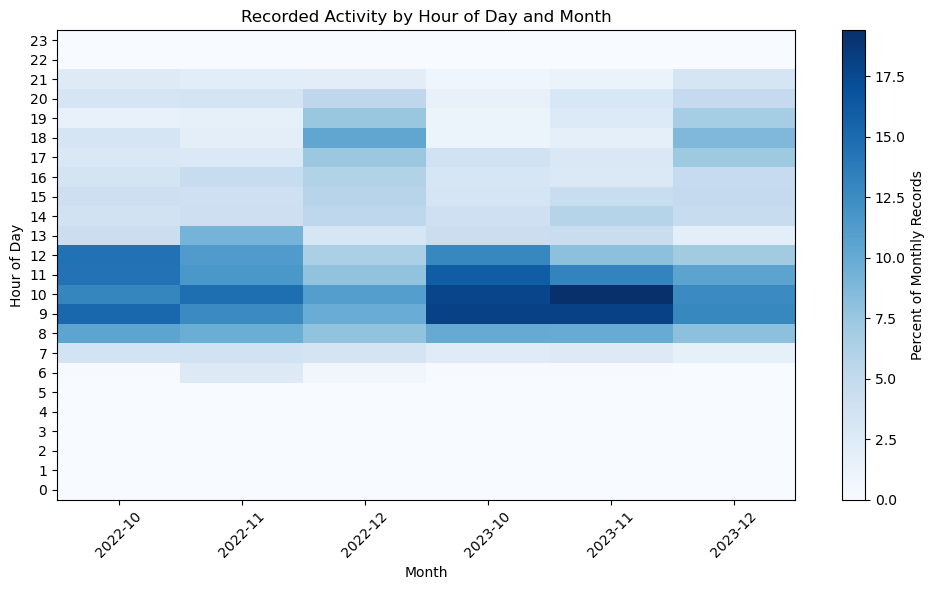

In [8]:
# Create a separate copy for the time-of-arrival analysis
df_full = df.copy()

# Ensure the appointment date is stored as datetime
df_full["Appointment Start Date"] = pd.to_datetime(
    df_full["Appointment Start Date"],
    errors="coerce"
)

# Display the number of records by selected month
print(
    df_full["Appointment Start Date"]
    .dt.strftime("%Y-%m")
    .value_counts()
    .sort_index()
)

# Retain records containing Time of Arrival
df_full = df_full[df_full["TOA"].notna()].copy()
df_full = df_full[
    df_full["TOA"].astype(str).str.strip() != ""
].copy()

# Clean and parse Time of Arrival
df_full["TOA_clean"] = df_full["TOA"].astype(str).str.strip()

df_full["toa_dt"] = pd.to_datetime(
    df_full["TOA_clean"],
    format="%b %d %Y %I:%M%p",
    errors="coerce"
)

# Exclude Time of Arrival values that could not be parsed
df_full = df_full.dropna(subset=["toa_dt"]).copy()

# Retain the selected comparison months
month_order = [
    "2022-10",
    "2022-11",
    "2022-12",
    "2023-10",
    "2023-11",
    "2023-12"
]

df_full["month_label"] = (
    df_full["Appointment Start Date"].dt.strftime("%Y-%m")
)

df_filtered = df_full[
    df_full["month_label"].isin(month_order)
].copy()

# Extract the hour from Time of Arrival
df_filtered["hour"] = df_filtered["toa_dt"].dt.hour

# Calculate visit counts by hour and month
heatmap_counts = (
    df_filtered.groupby(
        ["hour", "month_label"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(24), fill_value=0)
    .reindex(columns=month_order, fill_value=0)
)

# Convert counts into percentages within each month
heatmap_pct = (
    heatmap_counts
    .div(heatmap_counts.sum(axis=0), axis=1)
    .mul(100)
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(
    heatmap_pct,
    aspect="auto",
    origin="lower",
    cmap="Blues"
)

plt.colorbar(label="Percent of Monthly Records")
plt.title("Recorded Activity by Hour of Day and Month")
plt.xlabel("Month")
plt.ylabel("Hour of Day")
plt.xticks(
    ticks=range(len(month_order)),
    labels=month_order,
    rotation=45
)
plt.yticks(ticks=range(24), labels=range(24))
plt.tight_layout()
plt.show()

**Chart Type:** Bar Chart

**What this shows:**
This chart ranks the ten most frequently recorded meeting locations after standardizing the `Meeting Room` values and excluding noninformative entries.

**Insight:**
Some standardized meeting locations appear more frequently than others in the selected records.

**Why it matters:**
These differences identify locations that may warrant further operational review. The chart alone does not establish facility demand or required resource levels.

**Note:**
The chart excludes Room 1, Unknown, EW Tour, and Visitor’s Office so named locations can be displayed more clearly. Location values were standardized to address differences in capitalization, spacing, and hyphenation.

---

Visual 5: Recorded Activity by Hour of Day and Month


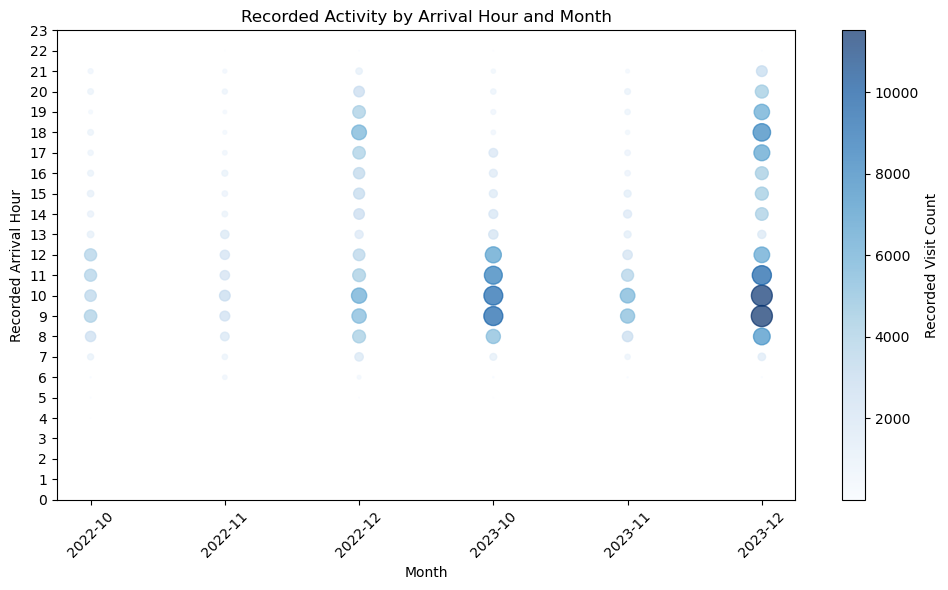

In [9]:
# Aggregate the TOA-filtered records by month and recorded arrival hour
scatter_data = (
    df_filtered.groupby(["month_label", "hour"])
    .size()
    .reset_index(name="count")
)

# Plot recorded activity
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    scatter_data["month_label"],
    scatter_data["hour"],
    s=scatter_data["count"] * 0.02,
    c=scatter_data["count"],
    cmap="Blues",
    alpha=0.7
)

plt.colorbar(scatter, label="Recorded Visit Count")
plt.title("Recorded Activity by Arrival Hour and Month")
plt.xlabel("Month")
plt.ylabel("Recorded Arrival Hour")
plt.yticks(range(24))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Chart Type:** Scatterplot with Time

**What this shows:**  
This scatterplot shows how visit activity is distributed across hours and months, with marker size representing the volume of visits.

**Insight:** Records with valid TOA values cluster around similar daytime hours across the selected months.

**Why it matters:** This visualization reinforces the timing pattern shown in the heatmap. Operational information would be required before translating the pattern into staffing or visitor-flow decisions.

-----------------------------------------------------------------------------------------------------------------
Visual 7 — Visits by Day of Week (Bar Chart)

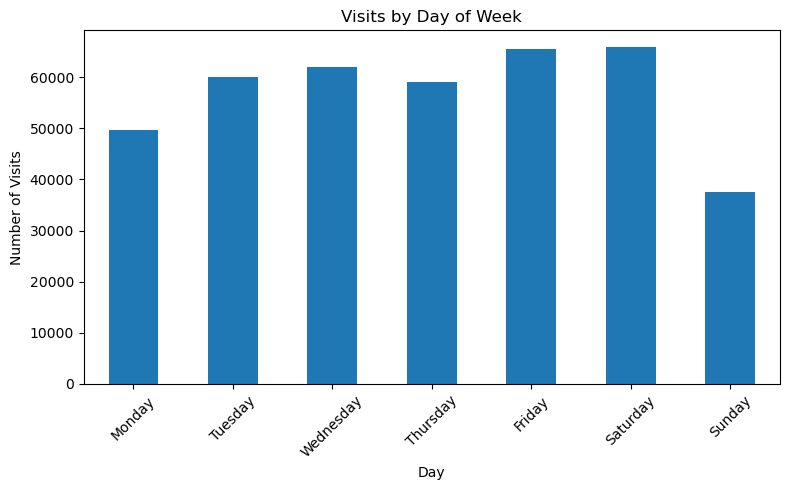

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
df['Appointment Start Date'] = pd.to_datetime(
    df['Appointment Start Date'], errors='coerce'
)

# Drop nulls
df = df.dropna(subset=['Appointment Start Date']).copy()

# Create day of week
df['day_of_week'] = df['Appointment Start Date'].dt.day_name()

# Ensure correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

visits_by_day = (
    df['day_of_week']
    .value_counts()
    .reindex(day_order)
)

# Plot
plt.figure(figsize=(8, 5))
visits_by_day.plot(kind='bar')

plt.title('Visits by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Chart Type:** Bar Chart

**What this shows:**  
This chart shows the distribution of visit activity across each day of the week.

**Insight:**  
Visit activity is concentrated during weekdays, with visibly lower recorded activity on weekends.

**Why it matters:**  
Recorded activity was higher on weekdays than on weekends during the selected periods. This pattern may provide context for operational review, but staffing decisions would require additional operational and event-specific information.

-----------------------------------------------------------------------------------------------------------------
Visual 8 — Step Chart of Monthly Visits (Step Chart)

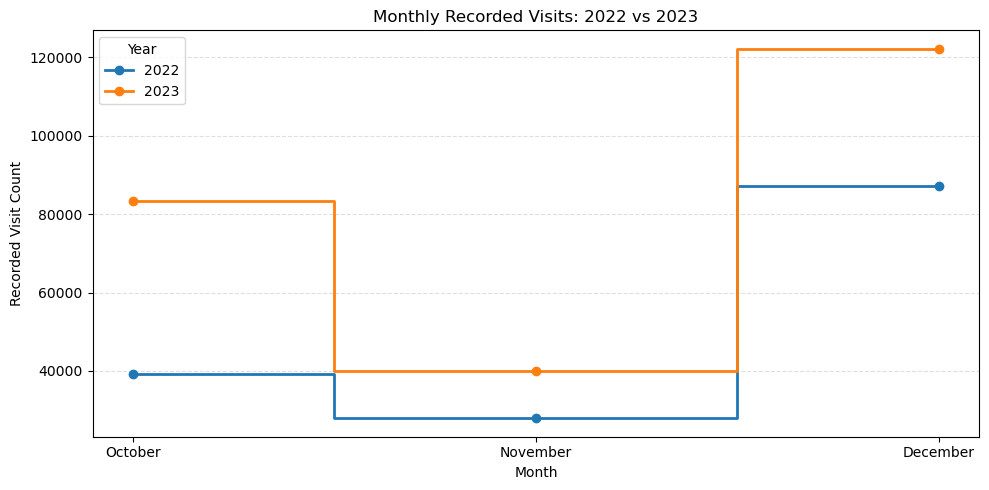

In [11]:
# Visual 8: Step Chart of Monthly Recorded Visits

# Create a separate dataframe so the main df is not changed
df_step = df.copy()

# Convert the appointment date
df_step["Appointment Start Date"] = pd.to_datetime(
    df_step["Appointment Start Date"],
    errors="coerce"
)

# Exclude records without a valid appointment date
df_step = df_step.dropna(
    subset=["Appointment Start Date"]
).copy()

# Create year and month fields
df_step["year"] = df_step["Appointment Start Date"].dt.year
df_step["month_num"] = df_step["Appointment Start Date"].dt.month

# Retain October through December of 2022 and 2023
df_step = df_step[
    df_step["year"].isin([2022, 2023])
    & df_step["month_num"].isin([10, 11, 12])
].copy()

# Count records by year and month
step_counts = (
    df_step.groupby(["year", "month_num"])
    .size()
    .reset_index(name="count")
)

# Plot each year as a separate step line
plt.figure(figsize=(10, 5))

for year in [2022, 2023]:
    year_data = (
        step_counts[step_counts["year"] == year]
        .set_index("month_num")
        .reindex([10, 11, 12])
    )

    plt.step(
        ["October", "November", "December"],
        year_data["count"],
        where="mid",
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Recorded Visits: 2022 vs 2023")
plt.xlabel("Month")
plt.ylabel("Recorded Visit Count")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Chart Type:** Step Chart

**What this shows:**
This step chart compares changes in recorded visit volume from October through December of 2022 and 2023. Each year is shown separately so the chart does not imply continuity across the months not included in the analysis.

**Insight:**
Recorded volume was higher in each selected 2023 month than in the corresponding 2022 month. October had the largest difference between the two selected periods.

**Why it matters:**
The comparison identifies differences within the selected months. It does not establish a complete year-over-year trend or independently demonstrate a need for staffing changes.

---



## Summary and Key Insights

The analysis of White House visitor records from October through December of 2022 and the same months in 2023 identified several differences and recurring patterns within the selected reporting periods.

Recorded activity was higher in each of the selected 2023 months than in the corresponding 2022 months. The line, bar, and step charts display this difference consistently. However, because the analysis includes only three months from each year, the results should not be interpreted as evidence of a full-year increase or a continuing long-term trend.

The named-visitee and meeting-location charts show that some visitees and locations appeared more frequently than others. A **visitee** is the person listed as being visited and should not be described as the person entering the White House. These frequency differences identify categories that may warrant additional operational review, but they do not establish influence, importance, unequal access, or the reason for a recorded visit.

The time-based visualizations show that recorded arrivals were more common during weekday business hours, particularly during the late morning and early afternoon. Weekend activity was substantially lower within the selected records. These findings describe historical patterns and may provide context for operational planning. Additional years, complete annual data, event schedules, staffing information, and security requirements would be needed before using the results to forecast demand or make resource-allocation decisions.

Overall, the analysis demonstrates how visitor-log data can be organized and visualized to support transparency and identify periods or categories for further review. The results should be treated as descriptive findings from the selected six-month period rather than proof of completed visits, operational demand, access equity, or future activity.

## Ethical Considerations

Six monthly visitor-log files were combined into one dataframe. Date fields were converted to datetime values, and derived fields were created for the year, month, day of the week, and hour. Visitee first and last names were combined for frequency analysis, and meeting-location values were standardized to address differences in capitalization, abbreviations, and spacing.

The Time of Arrival (`TOA`) field was treated as the **recorded arrival time**, not as independent confirmation that a visit began or was completed at that time. Records with missing or invalid `TOA` values were excluded only from visualizations that required an arrival hour. This exclusion may affect the time-based results if missing values were not distributed evenly across months or categories.

Each row was counted as a recorded visit for analytical purposes. The available fields do not independently confirm that every scheduled or recorded access event resulted in a completed visit. The dataset may also contain group entries, duplicate names, people with the same name, inconsistent labels, or other record-keeping differences that affect aggregated counts.

The analysis is limited to October through December of 2022 and 2023. Comparing the same months creates a consistent comparison window, but it does not eliminate the effects of holidays, special events, policy changes, reporting practices, or other differences between the two periods. The findings therefore should not be generalized to the complete calendar years.

White House visitor logs are public records intended to support government transparency. Nevertheless, they contain names and information about real people. Public availability does not justify drawing unsupported conclusions about an individual’s intentions, relationships, political influence, or importance.

Most findings are presented as aggregated patterns. The named-visitee visualization is an exception because it displays publicly recorded individual names. That chart is clearly identified as a count of **visitee-field appearances**, and it is not presented as a ranking of visitors, influence, or completed meetings.

To reduce the risk of misleading interpretation:

1. Visitors and visitees are clearly distinguished.
2. Data transformations, exclusions, and assumptions are documented.
3. Findings are limited to the selected reporting periods.
4. Recorded rows are not represented as independently verified completed visits.
5. Frequency is not treated as evidence of influence or unequal access.
6. Operational recommendations are framed as areas for further review rather than final decisions.
7. Visualizations use clear titles, labels, and contextual explanations, consistent with responsible data-communication practices (Cairo, 2016; Knaflic, 2015; Munzner, 2014).

## References

Cairo, A. (2016). *The truthful art: Data, charts, and maps for communication*. New Riders.

Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. Wiley.

Munzner, T. (2014). *Visualization analysis and design*. CRC Press.
